### Half-moon distribution with Diffusion Model 

- Diffusion Model is one of generative AI tool to learn a complex distribution by slowly destroying the complex structure by a process call adding noise. Then, it learn to reverse (a.k.a denoise) back to the complex one.

- This diffusion model is a more complex version of Gaussian Mixture Model. [TODO - understand]

- To train the diffusion model, we use a neural network to learn by minimize a KL divergence

- Some technique to accelerate the training step is to use alternative objective function which depend only on start(x_0) and end (x_T) which help us to overcome the intermediate samples.

In this notebook, the author will:

1. Implement/Train Diffusion Model from the scratch to generate Half-moon Distribution
2. Accelerate the training process.
3. Try and test the code using School HPC Server. 

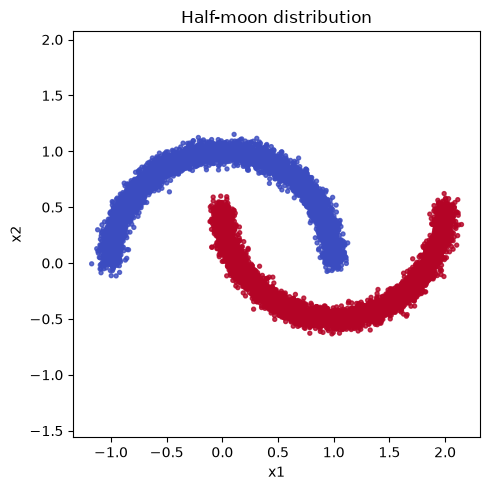

X shape: (10000, 2), y shape: (10000,)


In [22]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

n_samples = 10000
noise = 0.05
X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=8, cmap="coolwarm", alpha=0.8)
plt.title("Half-moon distribution")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.tight_layout()
plt.show()

print(f"X shape: {X.shape}, y shape: {y.shape}")


### Declare Neural Network Architecture 

In [23]:
import jax
import jax.numpy as jnp
from flax import nnx


class ScoreNet(nnx.Module):
    """Score network s_theta(x, t) -> R^2.
    Input: x=(x1, x2), t=time. Output: estimated score.
    """

    def __init__(self, hidden_dim: int = 128, n_hidden: int = 5, *, rngs: nnx.Rngs):
        self.hidden = nnx.List(
            [
                nnx.Linear(3 if i == 0 else hidden_dim, hidden_dim, rngs=rngs)
                for i in range(n_hidden)
            ]
        )
        self.out = nnx.Linear(hidden_dim, 2, rngs=rngs)

    def __call__(self, x, t):
        # x: (..., 2), t: (...,) or (..., 1) -> concat to (..., 3)
        t = t.reshape(x.shape[:-1] + (1,))
        h = jnp.concatenate([x, t], axis=-1)

        for layer in self.hidden:
            h = jax.nn.relu(layer(h))

        return self.out(h)  # score (s1, s2)


# quick shape check
model = ScoreNet(rngs=nnx.Rngs(0))
x_ex = jnp.zeros((4, 2))
t_ex = jnp.zeros((4,))
out = model(x_ex, t_ex)
print("output shape:", out.shape)


output shape: (4, 2)


In [24]:
import jax
import optax
from tqdm import trange

# hyperparameters
n_iterations = 10_000
batch_size = 128
T = 1.0
epsilon = 1.0 
t_min = 1e-3  # avoid division by zero when t ~ 0
lr = 1e-3

data = jnp.asarray(X)  # (N, 2)

model = ScoreNet(rngs=nnx.Rngs(0))
optimizer = nnx.Optimizer(model, optax.adam(lr), wrt=nnx.Param)


def loss_fn(model, x0, t, x_t):
    # weighted DSM: lambda(t) = t * epsilon  (stabilizes loss scale across t)
    # E[ lambda(t) * || s_theta(x_t, t) + (x_t - x0) / (t * epsilon) ||^2 ]
    score = model(x_t, t)
    target = (x_t - x0) / (t[:, None] * epsilon)
    per_sample = jnp.sum((score + target) ** 2, axis=-1)  # (batch,)
    return jnp.mean((t * epsilon) * per_sample)


@nnx.jit
def train_step(model, optimizer, x0, key):
    key_t, key_noise = jax.random.split(key)
    t = jax.random.uniform(key_t, (x0.shape[0],), minval=t_min, maxval=T)
    # x_t ~ N(x0, t * epsilon * I)
    noise = jax.random.normal(key_noise, x0.shape)
    x_t = x0 + jnp.sqrt(t[:, None] * epsilon) * noise

    loss, grads = nnx.value_and_grad(loss_fn)(model, x0, t, x_t)
    optimizer.update(model, grads)
    return loss


key = jax.random.PRNGKey(0)
losses = []
for i in trange(n_iterations):
    key, k_batch, k_step = jax.random.split(key, 3)
    idx = jax.random.choice(k_batch, data.shape[0], shape=(batch_size,), replace=False)
    x0 = data[idx]
    loss = train_step(model, optimizer, x0, k_step)
    losses.append(float(loss))
    if (i + 1) % 500 == 0:
        print(f"iter {i+1}/{n_iterations}  loss={loss:.4f}")


  5%|███                                                      | 531/10000 [00:02<00:41, 228.20it/s]

iter 500/10000  loss=1.3677


 10%|█████▊                                                  | 1037/10000 [00:04<00:39, 226.97it/s]

iter 1000/10000  loss=1.2024


 15%|████████▋                                               | 1544/10000 [00:07<00:37, 226.04it/s]

...

iter 9000/10000  loss=1.0171


 95%|█████████████████████████████████████████████████████▍  | 9545/10000 [00:42<00:02, 225.23it/s]

iter 9500/10000  loss=1.2198


100%|███████████████████████████████████████████████████████| 10000/10000 [00:44<00:00, 223.29it/s]

iter 10000/10000  loss=1.0743


/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_61976/2464102567.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


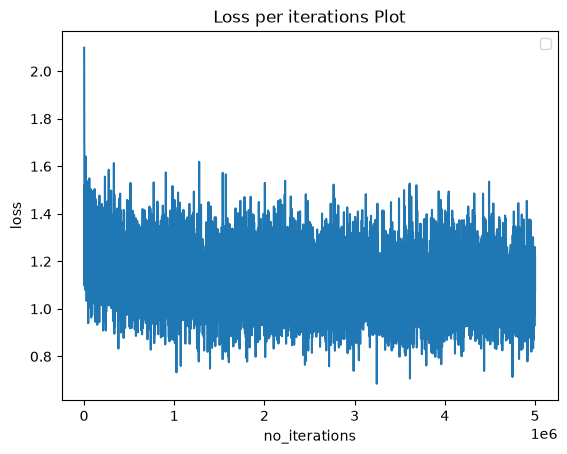

In [25]:
import matplotlib.pyplot as plt 
import numpy as np 

fig, ax = plt.subplots()

x = np.array([(i + 1) * 500 for i in range(1, len(losses) + 1)])
ax.plot(x, losses)

# 4. Customize the specific axes
ax.set_title('Loss per iterations Plot')
ax.set_xlabel('no_iterations')
ax.set_ylabel('loss')
ax.legend()

# 5. Display the plot
plt.show()


### Sample using our Neural Network

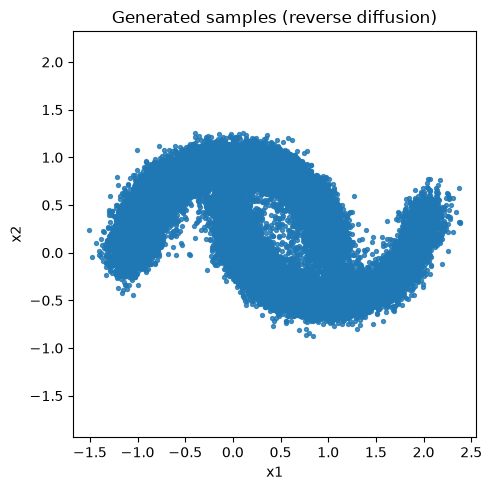

In [26]:
def generate_one(model, key, n_steps=200):
    """Reverse from x_T ~ N(0, T * epsilon * I) to one sample x_0."""
    key, k_init = jax.random.split(key)
    x = jnp.sqrt(T * epsilon) * jax.random.normal(k_init, (2,))
    dt = (T - t_min) / n_steps  # time step size while going T -> t_min

    def step(i, carry):
        x, key = carry
        key, k_noise = jax.random.split(key)
        t = T - i * dt
        score = model(x[None, :], jnp.array([t]))[0]
        # reverse VE-SDE, Euler step t -> t-dt:
        # x <- x + epsilon * score * dt + sqrt(epsilon * dt) * z
        z = jax.random.normal(k_noise, (2,))
        x = x + epsilon * score * dt + jnp.sqrt(epsilon * dt) * z
        return x, key

    x, _ = jax.lax.fori_loop(0, n_steps, step, (x, key))
    return x


def generate_many(model, key, n_samples, n_steps=200):
    """Generate many points by vmapping generate_one."""
    keys = jax.random.split(key, n_samples)
    return jax.vmap(lambda k: generate_one(model, k, n_steps))(keys)


# test generation
key, gen_key = jax.random.split(key)
# n_steps = reverse diffusion steps (NOT n_iterations)
samples = generate_many(model, gen_key, n_samples=100000, n_steps=2000)

plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.8)
plt.title("Generated samples (reverse diffusion)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.tight_layout()
plt.show()
